[*********************100%***********************]  1 of 1 completed


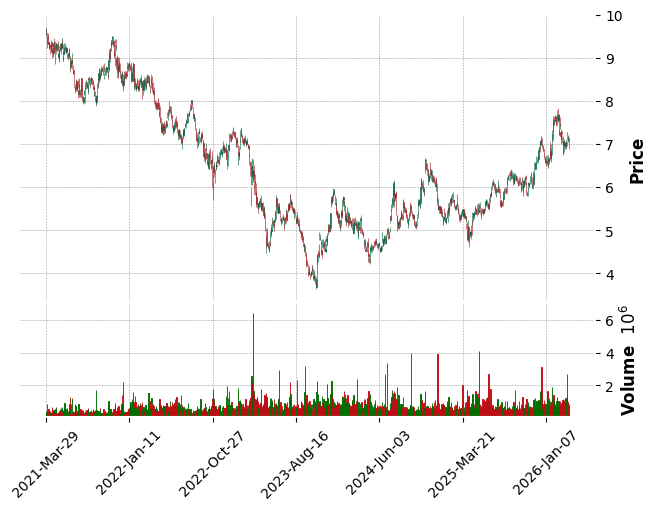

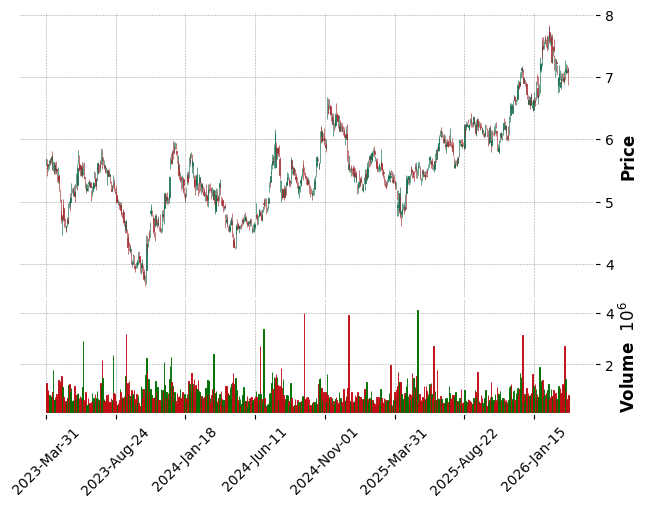

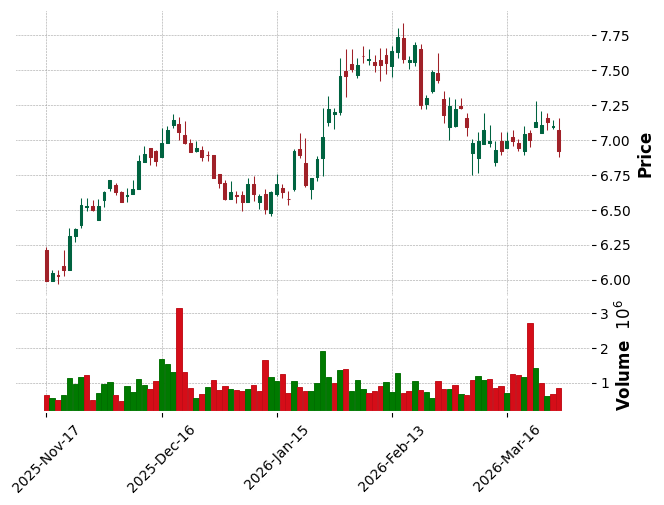

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


75.86916666666666


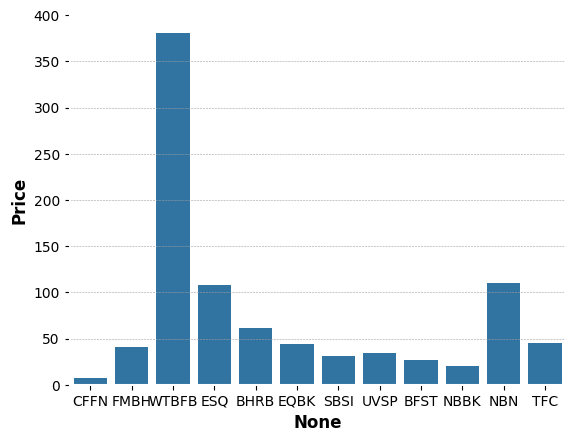

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bullish (Net Buy): 25,901 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-04 21:28:00
U.S. Bank Stocks Trade Down In February

https://finnhub.io/api/news?id=bf69f6c9c1bd41f665f48475881a4602c9a27b0ef0bf0150330e16deb71e382a

2026-02-08 14:55:01
Capitol Federal Financial Is Finally Moving In The Right Direction
Capitol Federal Financial's loan diversification and cost control are improving net interest margin and efficiency. Read why CFFN stock is rated a cautious Buy.
https://finnhub.io/api/news?id=64ceb3dd3e6b9e1298a2f5582f2190eb15c03d345c86f7b2d4b5c2192dcf6c2c

2026-01-29 05:44:16
Keefe, Bruyette & Woods Maintains Market Perform on Capitol Federal Finl, Raises Price Target to $7.5
Keefe, Bruyette &amp; Woods  analyst Damon Delmonte   maintains Capitol Federal Finl (NASDAQ:CFFN) with a Market Perform and raises the price target from $6.5 to $7.5.
https://finnhub.io/api/news?id=c02d7382833258f8b008545eafff64c10aa196b77ecd6aea64b8df5758302f60

2026-01-28 03:02:31
Capitol Federal Finl Q1 EPS $0.16 Beats $0.14 Estimate, Sales $56.796M Miss $57.511M Estim

In [9]:
inflect = Fun.get_inflections()

KeyError: 'eps'

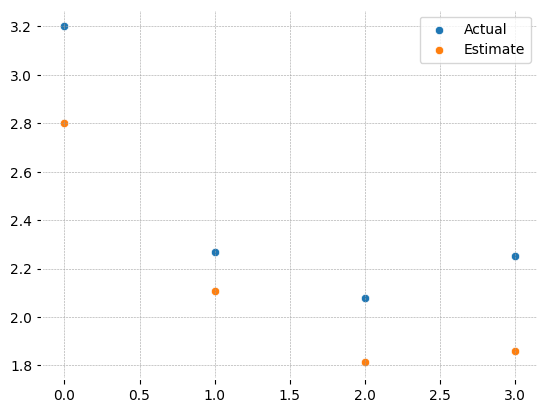

In [ ]:
surprise = Fun.eps_surprise()

2021-12-31   1719371000.00
2022-12-31   2329057000.00
2023-12-31   2875913000.00
2024-12-31   3304329000.00
Name: Total Revenue, dtype: float64
Revenue: [1.719371e+09 2.329057e+09 2.875913e+09 3.304329e+09]


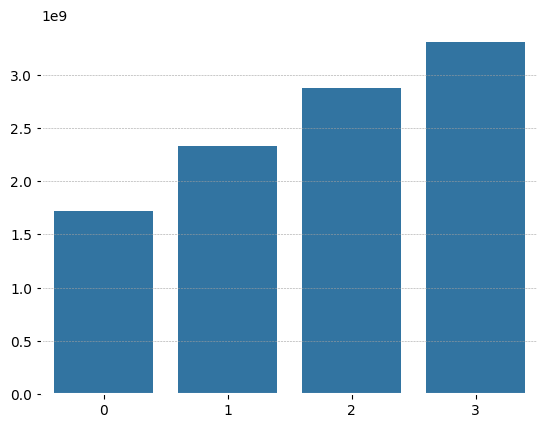

In [ ]:
revenue = Fun.revenue_growth()

In [ ]:
dcf = Fun.calculate_dcf()

Current FCF for CFFN: $49,839,000.00
